In [1]:
import cv2
import ale_py
import gymnasium as gym

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack, SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import os
import time
import json
import glob
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
gym.register_envs(ale_py)

In [4]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [5]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [6]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [7]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- CORREÇÃO DE ESCALA ---
    # A imagem da IA tem apenas 84x84 pixels.
    # Tamanho da Mancha: 40x40 pixels.
    # Centralização X: (84 - 40) / 2 = 22.
    
    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=25: Centraliza a mancha na massa de tijolos coloridos.
        'top':    (32, 25, 20, 20), 

        # ZONA 2: MIDDLE (TRAJETÓRIA)
        # Y=50: Fica no espaço vazio logo acima da linha de perigo.
        'middle': (32, 50, 20, 20), 

        # ZONA 3: BOTTOM (PADDLE)
        # Y=64: Vai exatamente até o pixel 84 (64+20=84).
        # Cobre apenas o centro do paddle, exigindo precisão.
        'bottom': (32, 64, 20, 20)  
    }
    
    region = presets.get(zone, (22, 38, 40, 40))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        
        # 1. Redimensiona PRIMEIRO (O mundo vira 84x84 aqui)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 2. Aplica a Mancha DEPOIS (Usando as coordenadas convertidas acima)
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [8]:
def make_ppo_multiprocess_env(
    n_envs=8,
    with_blur=False,
    change="white_patch",
    zone="middle",
    log_dir="./logs_ppo/",
):
    """
    Cria N ambientes rodando em paralelo para o PPO.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- COORDENADAS 20x20 ---
    presets = {
        "top": (32, 25, 20, 20),
        "middle": (32, 50, 20, 20),
        "bottom": (32, 64, 20, 20),
    }
    region = presets.get(zone, (32, 50, 20, 20))

    # Função Fábrica
    def wrapper_maker():
        # --- CORREÇÃO AQUI ---
        import gymnasium as gym
        import ale_py

        # Garante que o ambiente Atari seja registrado NESTE processo
        try:
            gym.register_envs(ale_py)
        except Exception:
            pass  # Ignora se já estiver registrado
        # ---------------------

        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)

        env = gym.wrappers.ResizeObservation(env, (84, 84))

        if change == "white_patch":
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == "blur":
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)

        env = GrayscaleWrapper(env)

        if log_dir:
            env = Monitor(env, log_dir)
        return env

    env = make_vec_env(wrapper_maker, n_envs=n_envs, vec_env_cls=SubprocVecEnv)

    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    return env

In [9]:
def make_eval_env(with_blur=False, zone='middle', render_mode=None):
    presets = {
        'top':    (32, 25, 20, 20), 
        'middle': (32, 50, 20, 20), 
        'bottom': (32, 64, 20, 20)
    }
    region = presets.get(zone, (32, 50, 20, 20))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode=render_mode)
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        if with_blur: # Aplica apenas se solicitado
            env = WhitePatchBreakout(env, apply_patch=True, region=region)
        env = GrayscaleWrapper(env)
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    return env

In [10]:
BASE_FOLDER = "treino_ppo_2"

In [11]:
def make_training_env(
    with_blur=False, change="white_patch", zone="middle", log_dir="./logs/"
):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- CORREÇÃO DE ESCALA ---
    # A imagem da IA tem apenas 84x84 pixels.
    # Tamanho da Mancha: 40x40 pixels.
    # Centralização X: (84 - 40) / 2 = 22.

    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=25: Centraliza a mancha na massa de tijolos coloridos.
        "top": (32, 25, 20, 20),
        # ZONA 2: MIDDLE (TRAJETÓRIA)
        # Y=50: Fica no espaço vazio logo acima da linha de perigo.
        "middle": (32, 50, 20, 20),
        # ZONA 3: BOTTOM (PADDLE)
        # Y=64: Vai exatamente até o pixel 84 (64+20=84).
        # Cobre apenas o centro do paddle, exigindo precisão.
        "bottom": (32, 64, 20, 20),
    }

    region = presets.get(zone, (22, 38, 40, 40))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)

        # 1. Redimensiona PRIMEIRO (O mundo vira 84x84 aqui)
        env = gym.wrappers.ResizeObservation(env, (84, 84))

        # 2. Aplica a Mancha DEPOIS (Usando as coordenadas convertidas acima)
        if change == "white_patch":
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == "blur":
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)

        env = GrayscaleWrapper(env)

        if log_dir:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)

        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    return env

In [12]:
def run_cross_eval(algo_class, base_folder, n_episodes=5):
    algo_name = algo_class.__name__
    prefix = "dqn" if algo_name == "DQN" else "ppo"

    # 1. Definir Caminhos dos Modelos
    agents = {"dqn": os.path.join(base_folder, "meu_breakout_corrigido.zip")}

    # 2. Configuração dos Ambientes de Teste
    envs_config = {
        "Amb. Normal": (False, 'middle'),
        "Amb. Top":    (True, 'top'),
        "Amb. Mid":    (True, 'middle'),
        "Amb. Bot":    (True, 'bottom')
    }

    results = []
    print(f"--- Iniciando Avaliação Cruzada ({algo_name}) ---")

    for ag_name, model_path in agents.items():
        # Tenta carregar com ou sem .zip
        path_to_load = model_path
        if not os.path.exists(path_to_load) and os.path.exists(path_to_load + ".zip"):
            path_to_load += ".zip"

        if not os.path.exists(path_to_load): 
            print(f"Pulei {ag_name} (Arquivo não encontrado: {path_to_load})")
            continue

        print(f"Avaliando Agente: {ag_name}...")
        try:
            model = algo_class.load(path_to_load)
        except Exception as e:
            print(f"Erro ao carregar modelo: {e}")
            continue

        for env_name, (blur, zone) in envs_config.items():
            # IMPORTANTE: Usar make_eval_env (DummyVecEnv) para teste, não o Multiprocess
            print(f"No ambiente: {env_name}...")
            env = make_training_env(with_blur=blur, zone=zone)

            rewards = []
            lengths = []

            for _ in range(n_episodes):
                print(f"Completos: {round(_+1/n_episodes*100,2)}%")
                obs = env.reset()
                done = [False] # Inicializa como lista para entrar no loop
                ep_r = 0
                ep_l = 0

                # CORREÇÃO DO ERRO AQUI:
                while not done[0]: 
                    action, _ = model.predict(obs, deterministic=True)
                    obs, r, done, _ = env.step(action)
                    ep_r += r[0]
                    ep_l += 1

                rewards.append(ep_r)
                lengths.append(ep_l)

            env.close()

            # Métricas
            mean_r = np.mean(rewards)
            mean_l = np.mean(lengths)
            efficiency = mean_r / (mean_l + 1e-6) * 100 

            results.append({
                "Agente": ag_name, "Ambiente": env_name, 
                "Score": mean_r, "Sobrevivência": mean_l, "Eficiência": efficiency
            })

    # --- PLOTAGEM ---
    if not results:
        print("Nenhum resultado gerado.")
        return

    df = pd.DataFrame(results)
    metrics = ["Score", "Sobrevivência", "Eficiência"]

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    for i, metric in enumerate(metrics):
        try:
            pivot = df.pivot(index="Agente", columns="Ambiente", values=metric)
            sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", ax=axes[i], linewidths=.5)
            axes[i].set_title(f"{metric} - {algo_name}")
        except Exception as e:
            print(f"Erro ao plotar {metric}: {e}")

    plt.tight_layout()
    plt.show()

    return df

In [16]:
from stable_baselines3.dqn.policies import CnnPolicy

In [17]:
original_init = CnnPolicy.__init__
def patched_init(self, *args, **kwargs):
    if 'use_sde' in kwargs:
        del kwargs['use_sde'] # Remove o argumento problemático
    original_init(self, *args, **kwargs)

CnnPolicy.__init__ = patched_init

--- Iniciando Avaliação Cruzada (PPO) ---
Avaliando Agente: dqn...
No ambiente: Amb. Normal...
Completos: 1.0%
Completos: 2.0%
Completos: 3.0%
Completos: 4.0%
Completos: 5.0%
Completos: 6.0%
Completos: 7.0%
Completos: 8.0%
Completos: 9.0%
Completos: 10.0%
Completos: 11.0%
Completos: 12.0%
Completos: 13.0%
Completos: 14.0%
Completos: 15.0%
Completos: 16.0%
Completos: 17.0%
Completos: 18.0%
Completos: 19.0%
Completos: 20.0%
Completos: 21.0%
Completos: 22.0%
Completos: 23.0%
Completos: 24.0%
Completos: 25.0%
Completos: 26.0%
Completos: 27.0%
Completos: 28.0%
Completos: 29.0%
Completos: 30.0%
Completos: 31.0%
Completos: 32.0%
Completos: 33.0%
Completos: 34.0%
Completos: 35.0%
Completos: 36.0%
Completos: 37.0%
Completos: 38.0%
Completos: 39.0%
Completos: 40.0%
Completos: 41.0%
Completos: 42.0%
Completos: 43.0%
Completos: 44.0%
Completos: 45.0%
Completos: 46.0%
Completos: 47.0%
Completos: 48.0%
Completos: 49.0%
Completos: 50.0%
Completos: 51.0%
Completos: 52.0%
Completos: 53.0%
Completos: 54

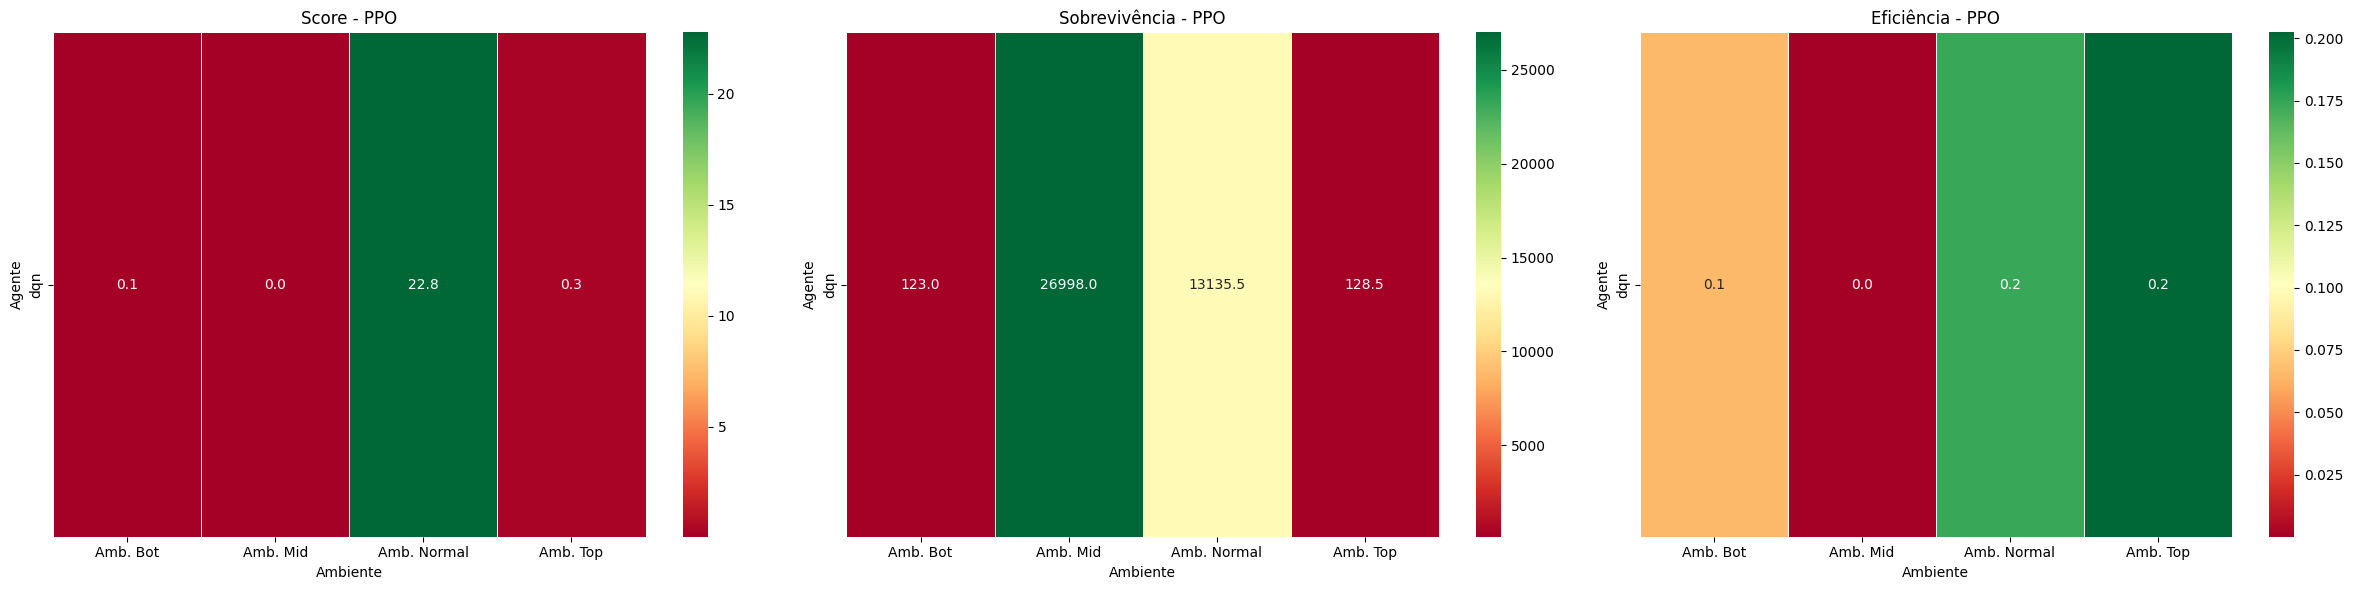

In [18]:
df = run_cross_eval(PPO, "logs", n_episodes=100)

In [14]:
BASE_FOLDER = "treino_ppo"

In [19]:
df

,Agente,Ambiente,Score,Sobrevivência,Eficiência
0,dqn,Amb. Normal,22.780001,13135.47,0.173424
1,dqn,Amb. Top,0.260000,128.47,0.202382
2,dqn,Amb. Mid,0.030000,26998.00,0.000111
3,dqn,Amb. Bot,0.080000,123.00,0.065041


In [20]:
df.to_csv("cross_eval_pre_trained_v2_dqn.csv", index=False)